# Stage 2 — DRS spectral shapes of difficult subjects
Generate target-specific baseline figures plus shared-scale comparisons with fine-tuned gated-residual DTOF-descriptor and tissue-thickness-feature models.

In [1]:
from pathlib import Path
import os, sys
import pandas as pd
ROOT = Path.cwd()
if not (ROOT / 'pyproject.toml').is_file():
    ROOT = ROOT.parent
if not (ROOT / 'pyproject.toml').is_file():
    raise RuntimeError('Open this notebook from final_refactored or its notebooks folder.')
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'src'))
from subject_nirs.stage2.subject_failure import (
    load_baseline_performance, load_or_compute_signatures,
    make_subject_failure_figure, make_subject_failure_comparison_figure,
    make_subject_failure_feature_comparison_figure,
)
BASELINE_DIRS = {
    'hc': Path('artifacts/stage2/baseline/hc'),
    'sto2': Path('artifacts/stage2/baseline/sto2'),
}
DTOF_DIRS = {
    'hc': Path('artifacts/stage2/residual/finetune/dtof/hc'),
    'sto2': Path('artifacts/stage2/residual/finetune/dtof/sto2'),
}
THICKNESS_DIRS = {
    'hc': Path('artifacts/stage2/residual/finetune/metadata/hc'),
    'sto2': Path('artifacts/stage2/residual/finetune/metadata/sto2'),
}
EXPECTED_SUBJECTS = 154
VALIDATION_CACHE = Path('cache/stage2/preprocessed_cache_grid_50k')
SIGNATURE_CACHE = Path('cache/stage2/subject_failure/subject_mean_signatures.npz')
FIGURE_DIR = Path('results/figures/stage2')
TABLE_DIR = Path('results/tables/stage2/subject_failure')

## 1. Build intensity-balanced subject signatures
For every subject, average the 30-channel relative-optical-density vectors within each tHb × StO₂ target cell and then equally across cells.

In [2]:
subject_ids, signatures = load_or_compute_signatures(
    SIGNATURE_CACHE,
    VALIDATION_CACHE / 'val_x_preprocessed.npy',
    VALIDATION_CACHE / 'val_y_all_targets.npy',
    VALIDATION_CACHE / 'val_subj_0based.npy',
    recompute=False,
)
subject_ids.shape, signatures.shape

((154,), (154, 30))

## 2. Generate baseline and feature-source comparison figures
Each model independently defines Q1/Q4 from its own held-out-subject RMSE and splits Q4 by its own signed Bias. The feature-source comparison uses the baseline Q1 median/MAD reference and one symmetric color scale across baseline, DTOF-descriptor, and tissue-thickness-feature rows. Thus color differences reflect changed difficult-group membership; neither subject feature changes the underlying DRS measurements.

,target,target_display,figure,common_n,accurate_n,difficult_n,overestimation_n,underestimation_n,zero_bias_difficult_n,rmse_q25,rmse_q75,overestimation_iqr_consistent_channels,underestimation_iqr_consistent_channels
0,hc,tHb,results/figures/stage2/subject_failure_hc.png,154,39,39,17,22,0,10.521772,17.889792,20,4
1,sto2,StO₂,results/figures/stage2/subject_failure_sto2.png,154,39,39,22,17,0,0.035095,0.069571,2,18


,target,target_display,figure,shared_color_limit,model,common_n,accurate_n,difficult_n,overestimation_n,underestimation_n,zero_bias_difficult_n,rmse_q25,rmse_q75,difficult_overlap_n,contrast_reference,overestimation_mean_abs_contrast,underestimation_mean_abs_contrast,overestimation_iqr_consistent_channels,underestimation_iqr_consistent_channels
0,hc,tHb,results/figures/stage2/subject_failure_compari...,1.833867,drs_only,154,39,39,17,22,0,10.521772,17.889792,39,drs_only_q1_median_and_mad,0.764023,0.353981,20,4
1,hc,tHb,results/figures/stage2/subject_failure_compari...,1.833867,residual_finetune_dtof,154,39,39,19,20,0,9.851041,17.161531,26,drs_only_q1_median_and_mad,0.669343,0.323140,13,5
2,sto2,StO₂,results/figures/stage2/subject_failure_compari...,1.471108,drs_only,154,39,39,22,17,0,0.035095,0.069571,39,drs_only_q1_median_and_mad,0.536538,0.893067,2,18
3,sto2,StO₂,results/figures/stage2/subject_failure_compari...,1.471108,residual_finetune_dtof,154,39,39,23,16,0,0.033888,0.066441,33,drs_only_q1_median_and_mad,0.507531,0.875602,3,16


,target,target_display,figure,shared_color_limit,model,common_n,accurate_n,difficult_n,overestimation_n,underestimation_n,zero_bias_difficult_n,rmse_q25,rmse_q75,difficult_overlap_n,contrast_reference,overestimation_mean_abs_contrast,underestimation_mean_abs_contrast,overestimation_iqr_consistent_channels,underestimation_iqr_consistent_channels
0,hc,tHb,results/figures/stage2/subject_failure_feature...,1.833867,drs_only,154,39,39,17,22,0,10.521772,17.889792,39,drs_only_q1_median_and_mad,0.764023,0.353981,20,4
1,hc,tHb,results/figures/stage2/subject_failure_feature...,1.833867,residual_finetune_dtof,154,39,39,19,20,0,9.851041,17.161531,26,drs_only_q1_median_and_mad,0.669343,0.323140,13,5
2,hc,tHb,results/figures/stage2/subject_failure_feature...,1.833867,residual_finetune_thickness,154,39,39,17,22,0,9.925406,15.685256,26,drs_only_q1_median_and_mad,0.686835,0.366822,16,5
3,sto2,StO₂,results/figures/stage2/subject_failure_feature...,1.471108,drs_only,154,39,39,22,17,0,0.035095,0.069571,39,drs_only_q1_median_and_mad,0.536538,0.893067,2,18
4,sto2,StO₂,results/figures/stage2/subject_failure_feature...,1.471108,residual_finetune_dtof,154,39,39,23,16,0,0.033888,0.066441,33,drs_only_q1_median_and_mad,0.507531,0.875602,3,16
5,sto2,StO₂,results/figures/stage2/subject_failure_feature...,1.471108,residual_finetune_thickness,154,39,39,20,19,0,0.034796,0.064741,33,drs_only_q1_median_and_mad,0.471938,0.847144,2,14


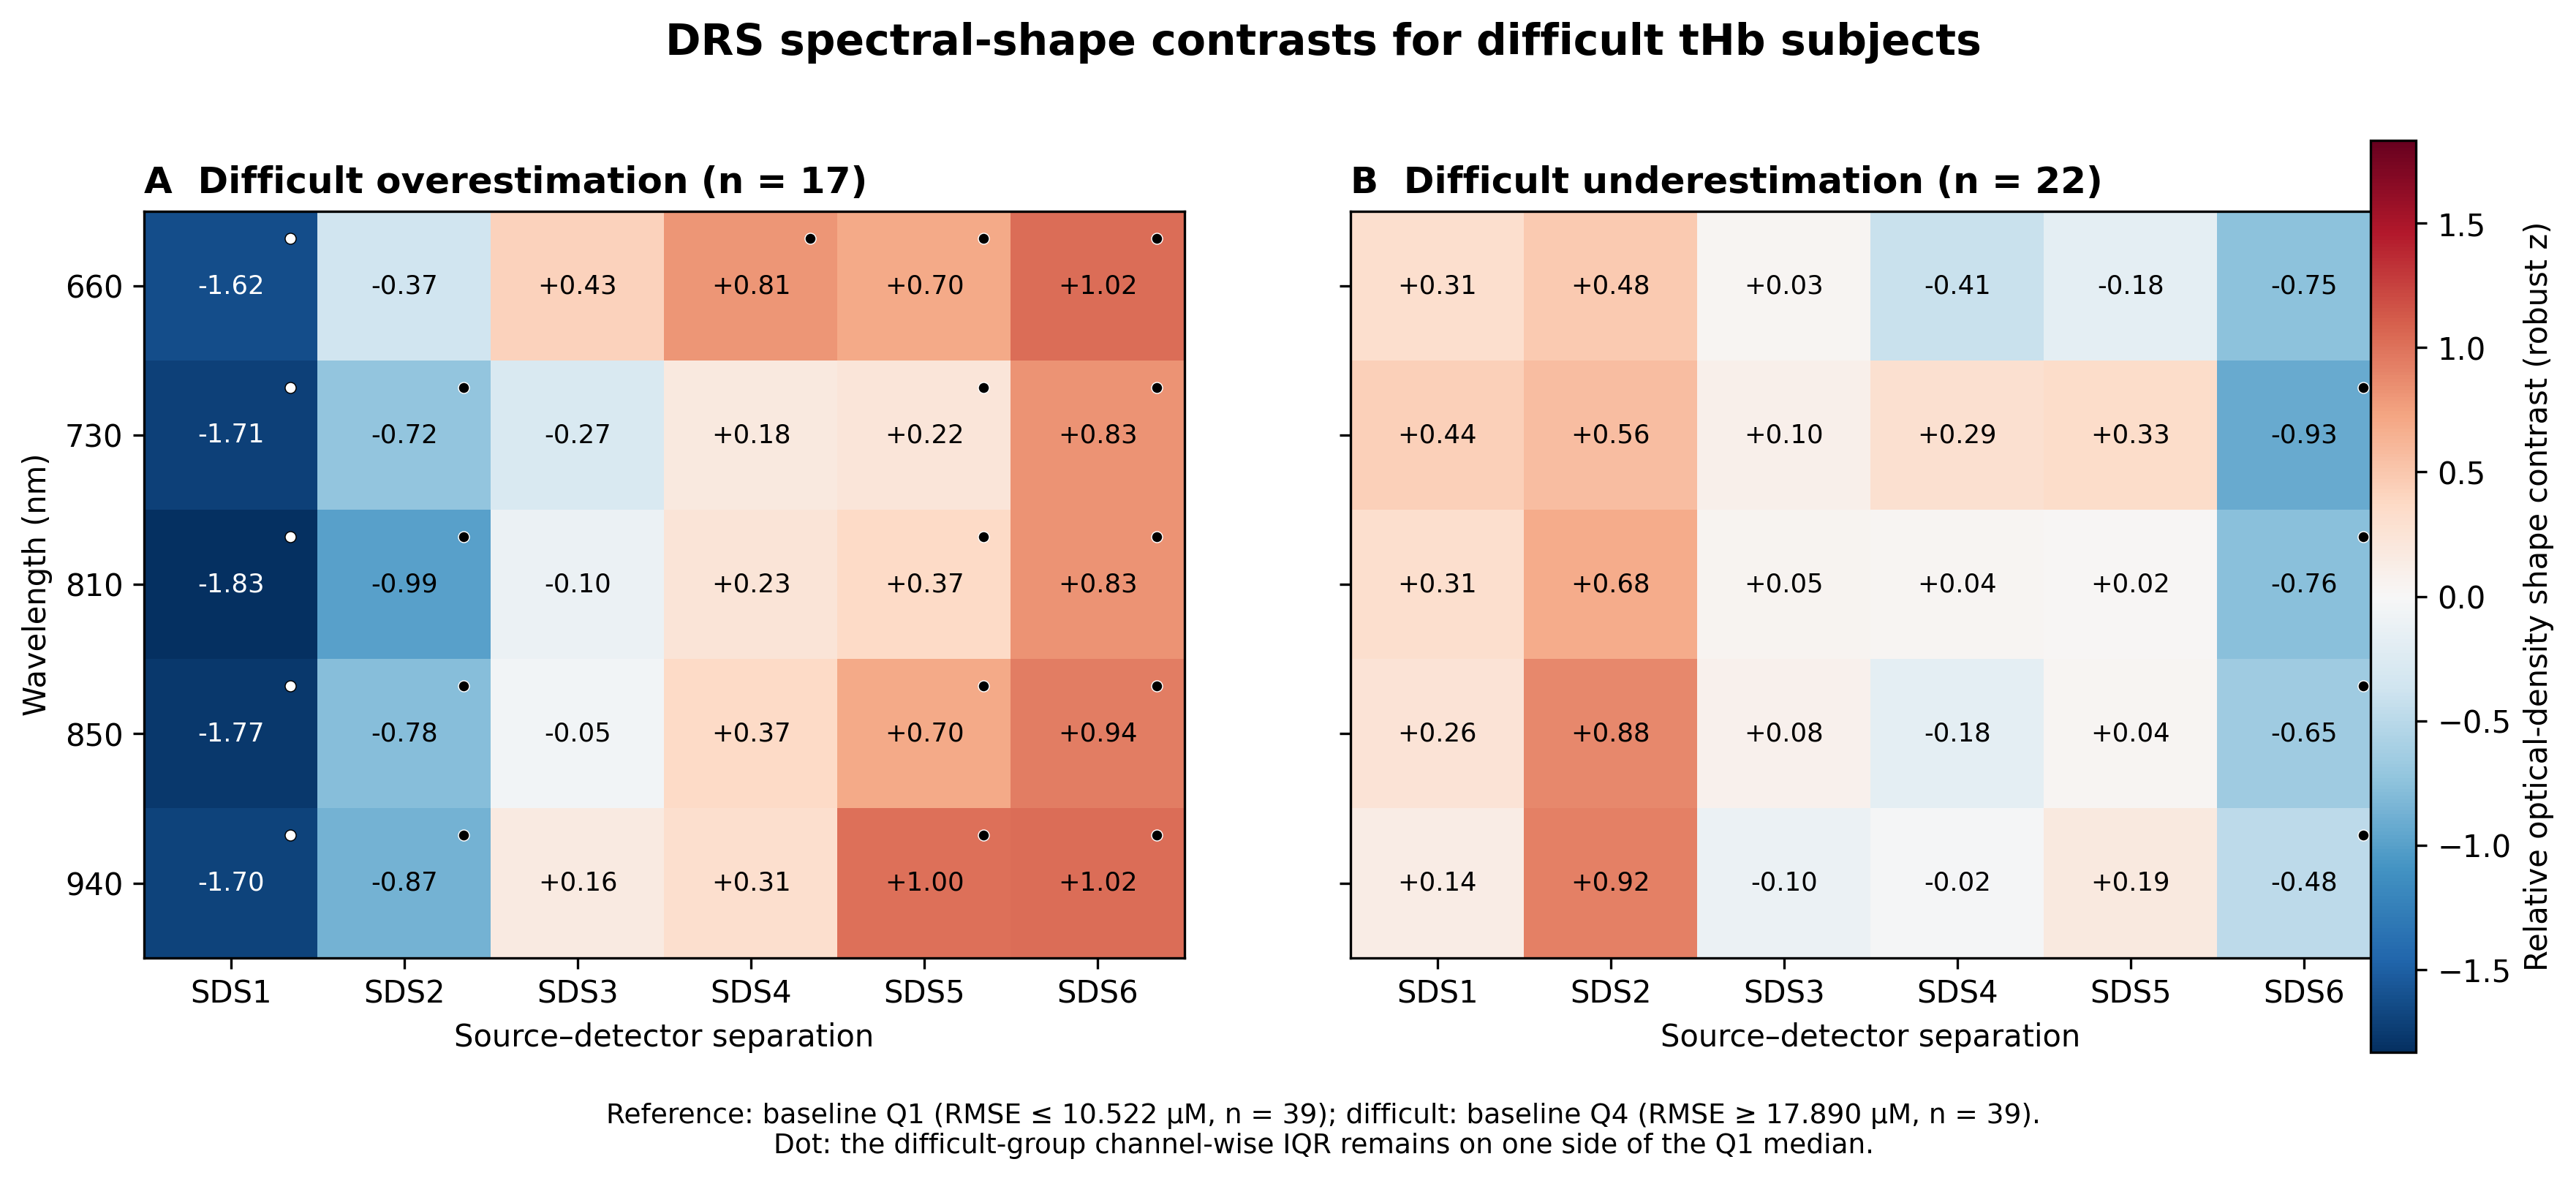

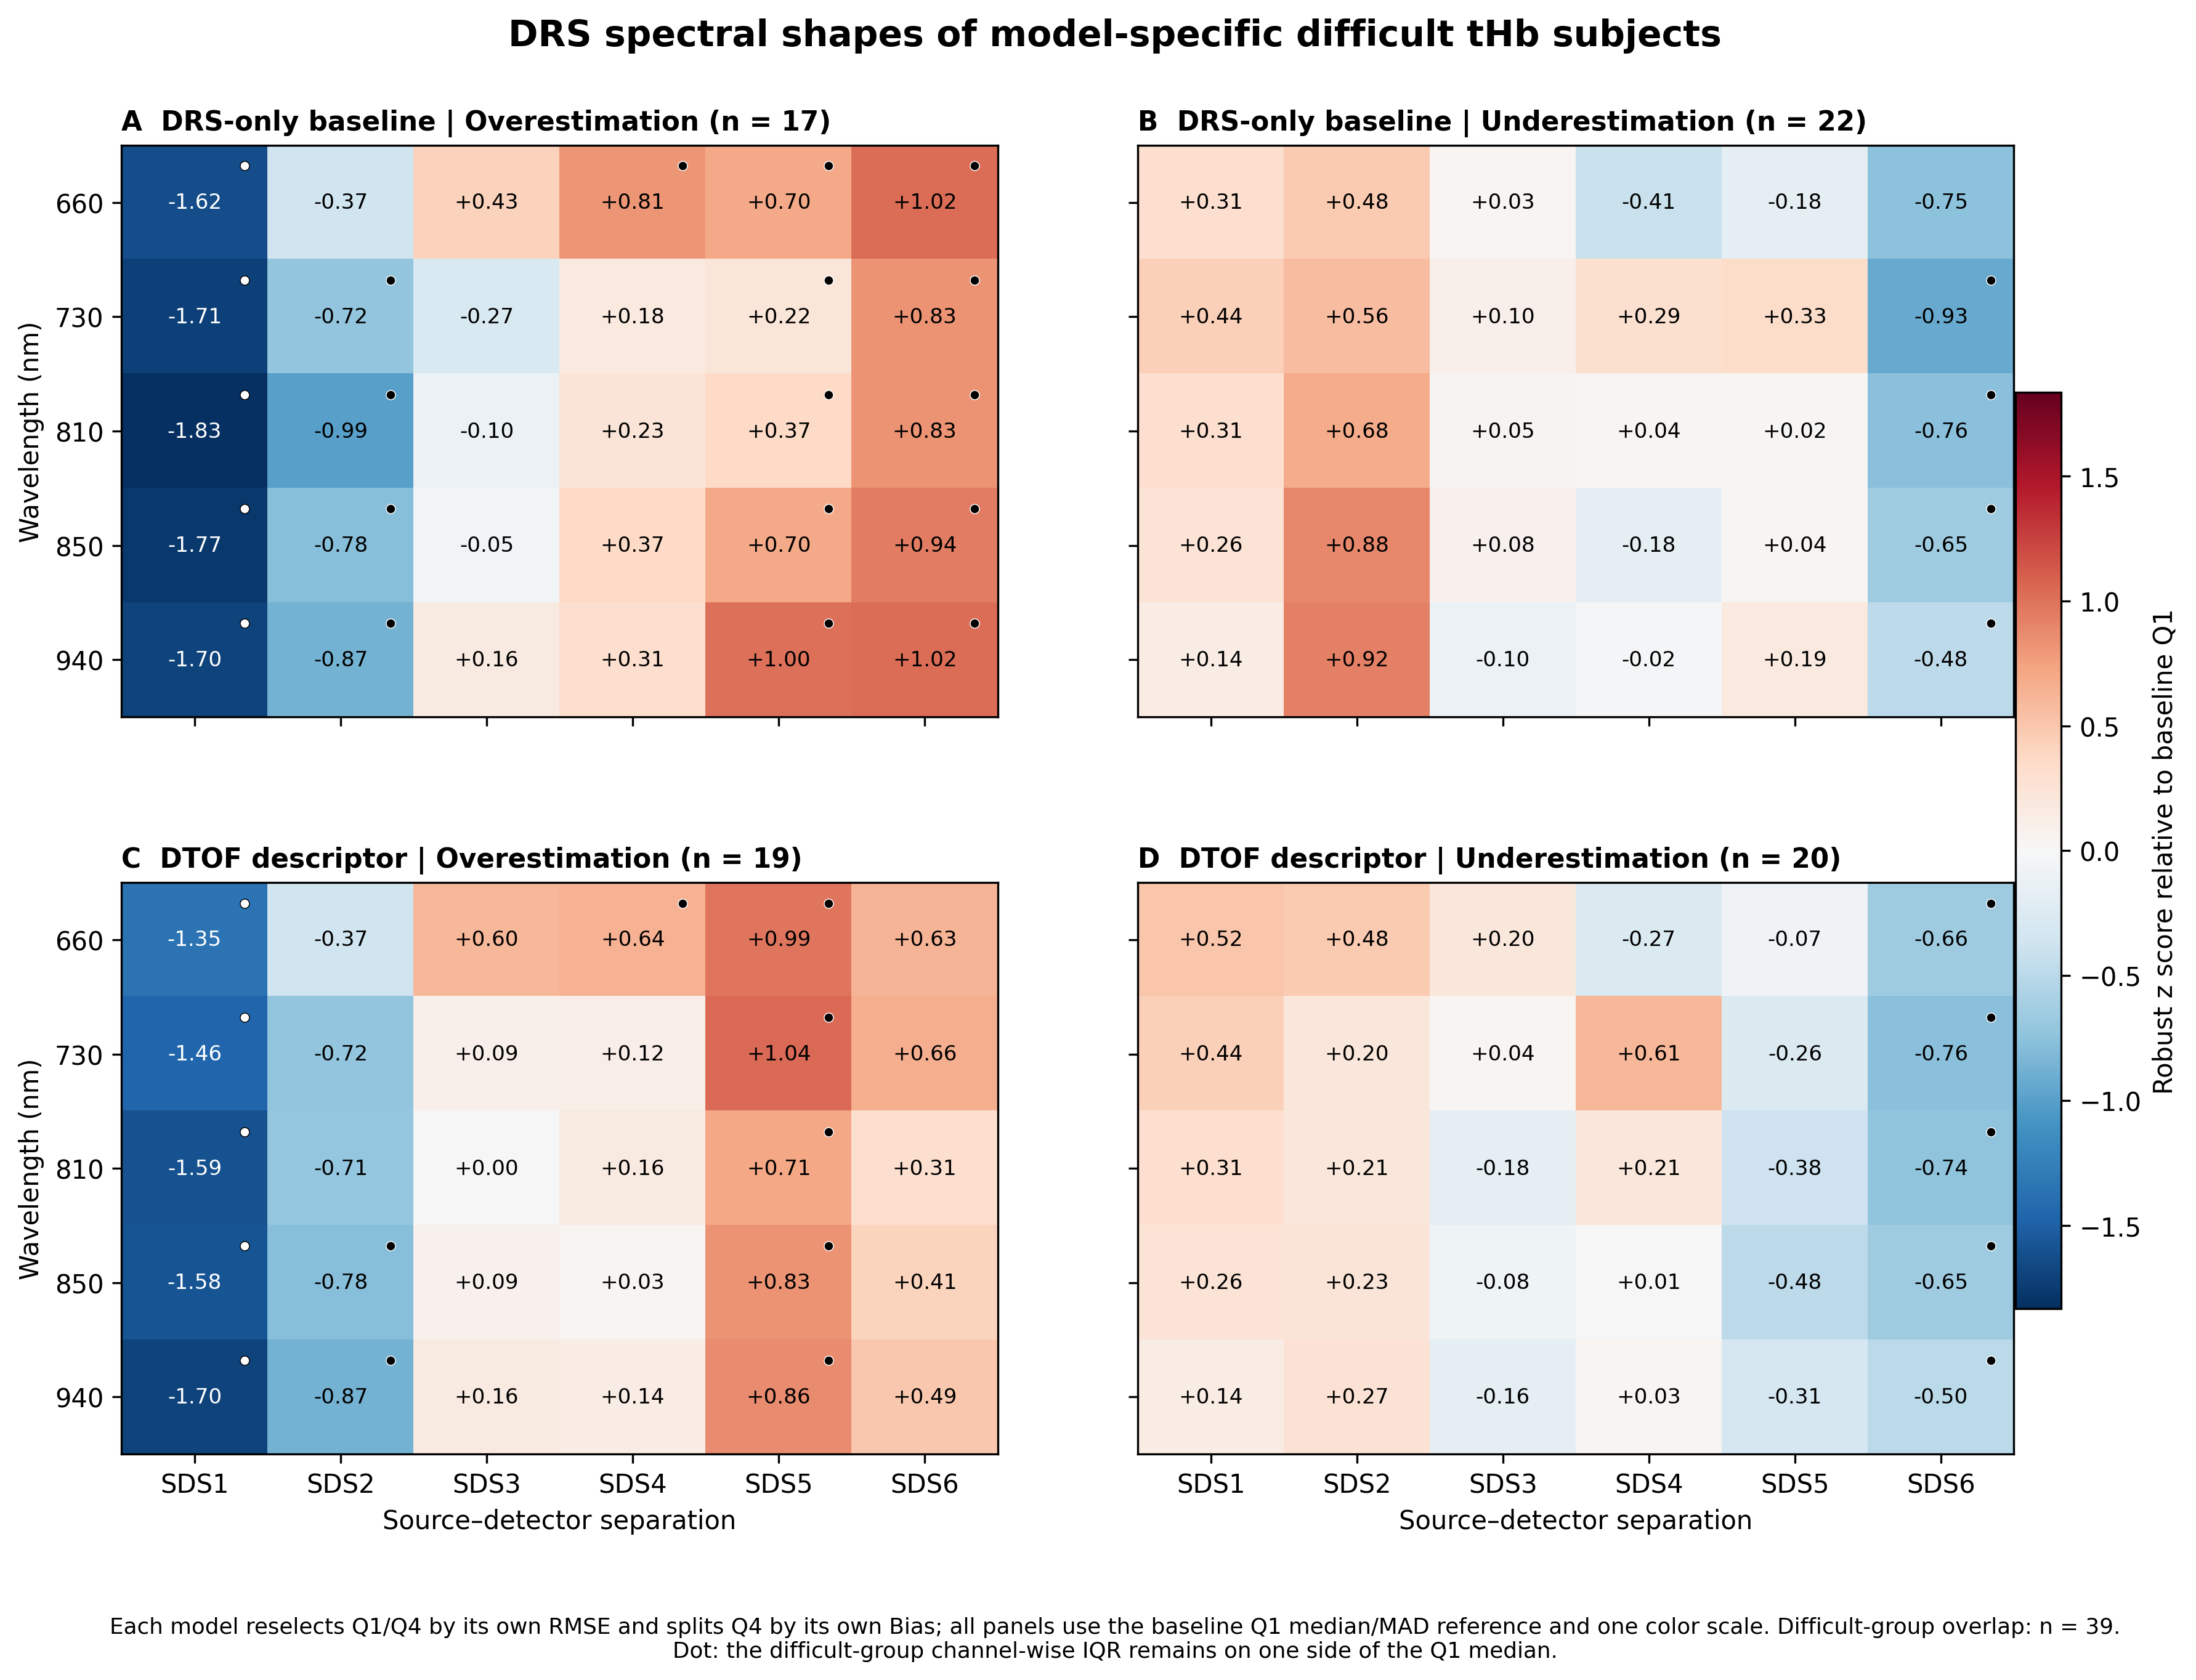

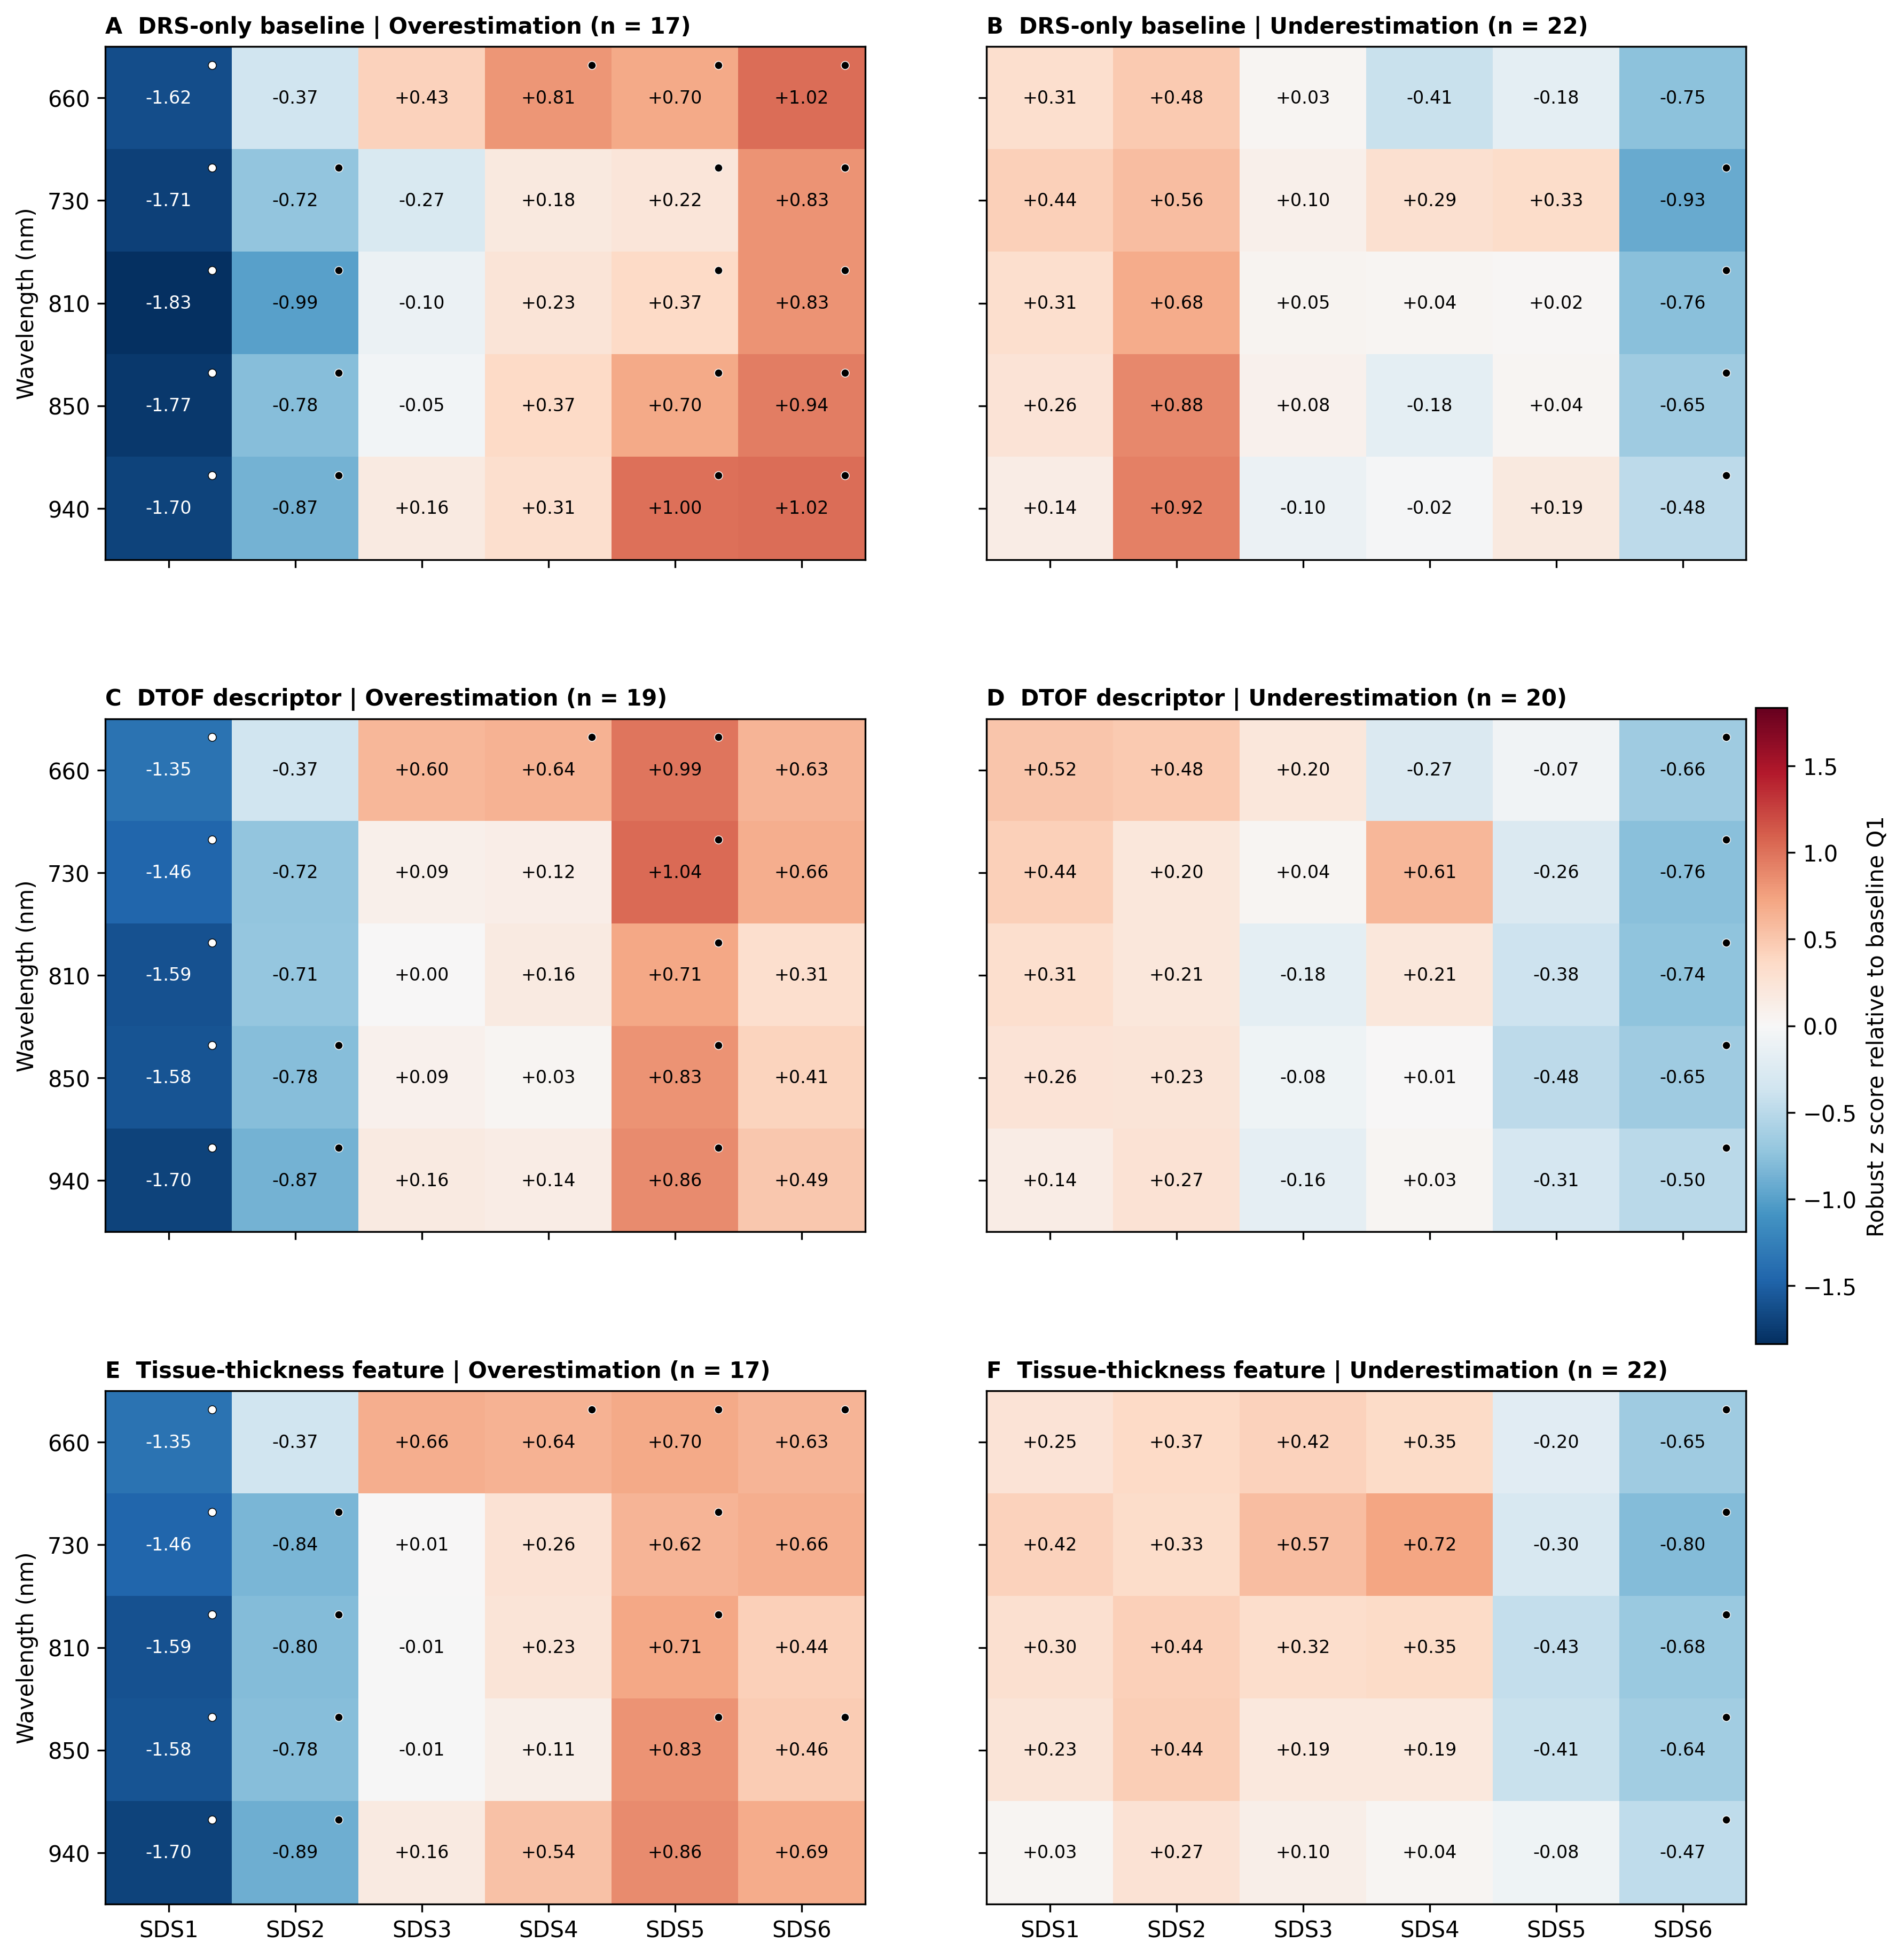

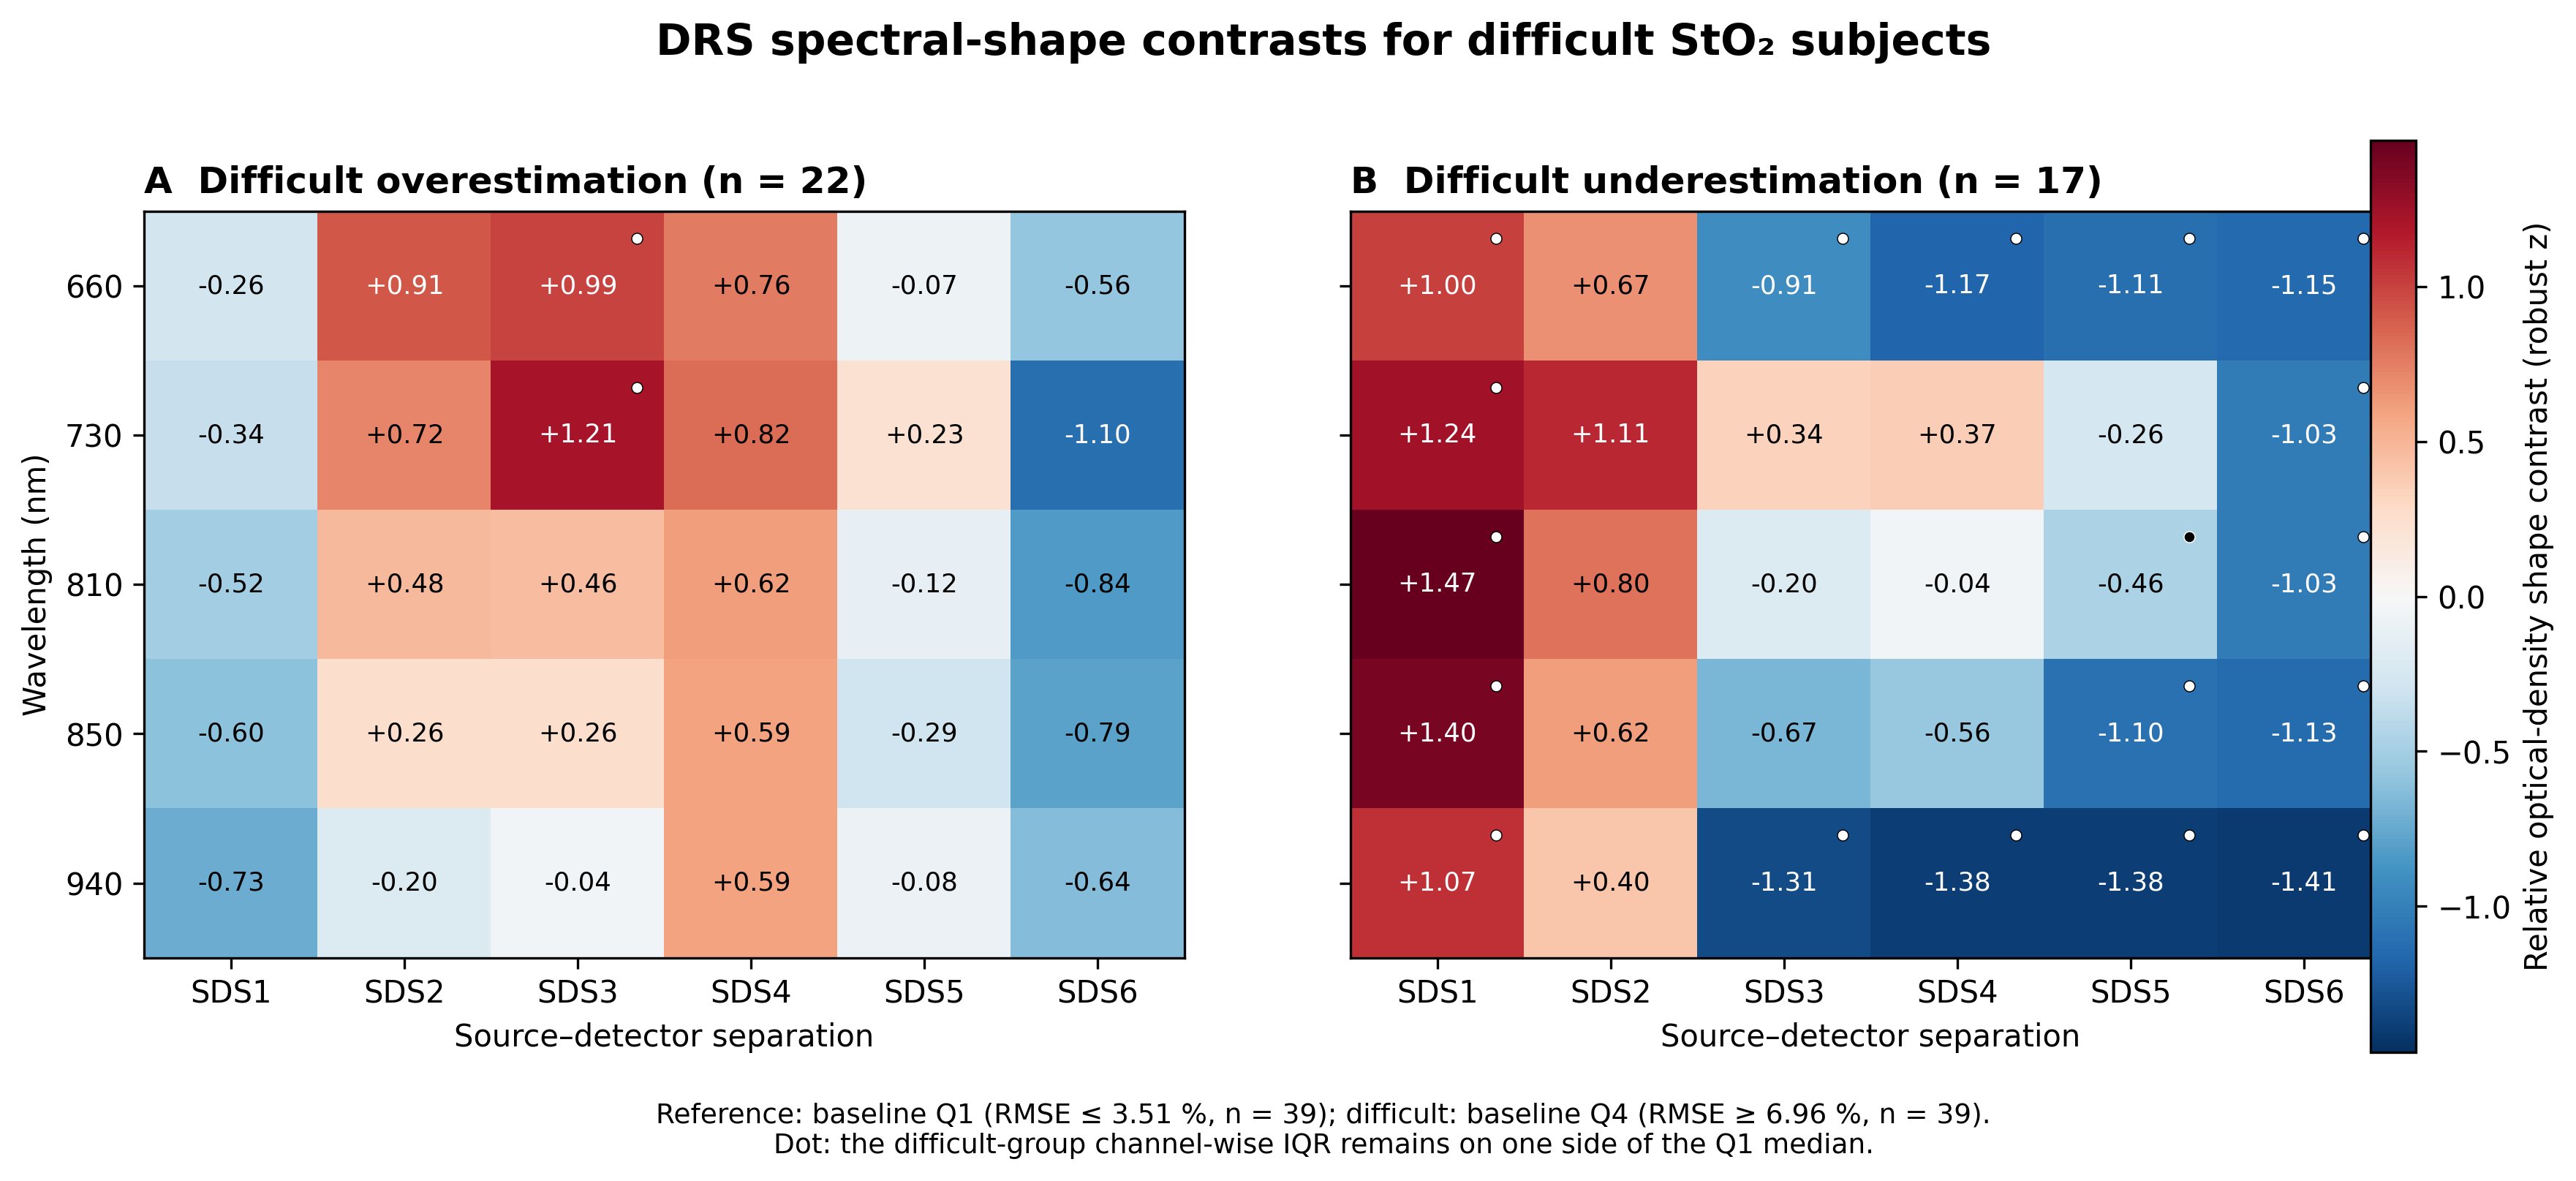

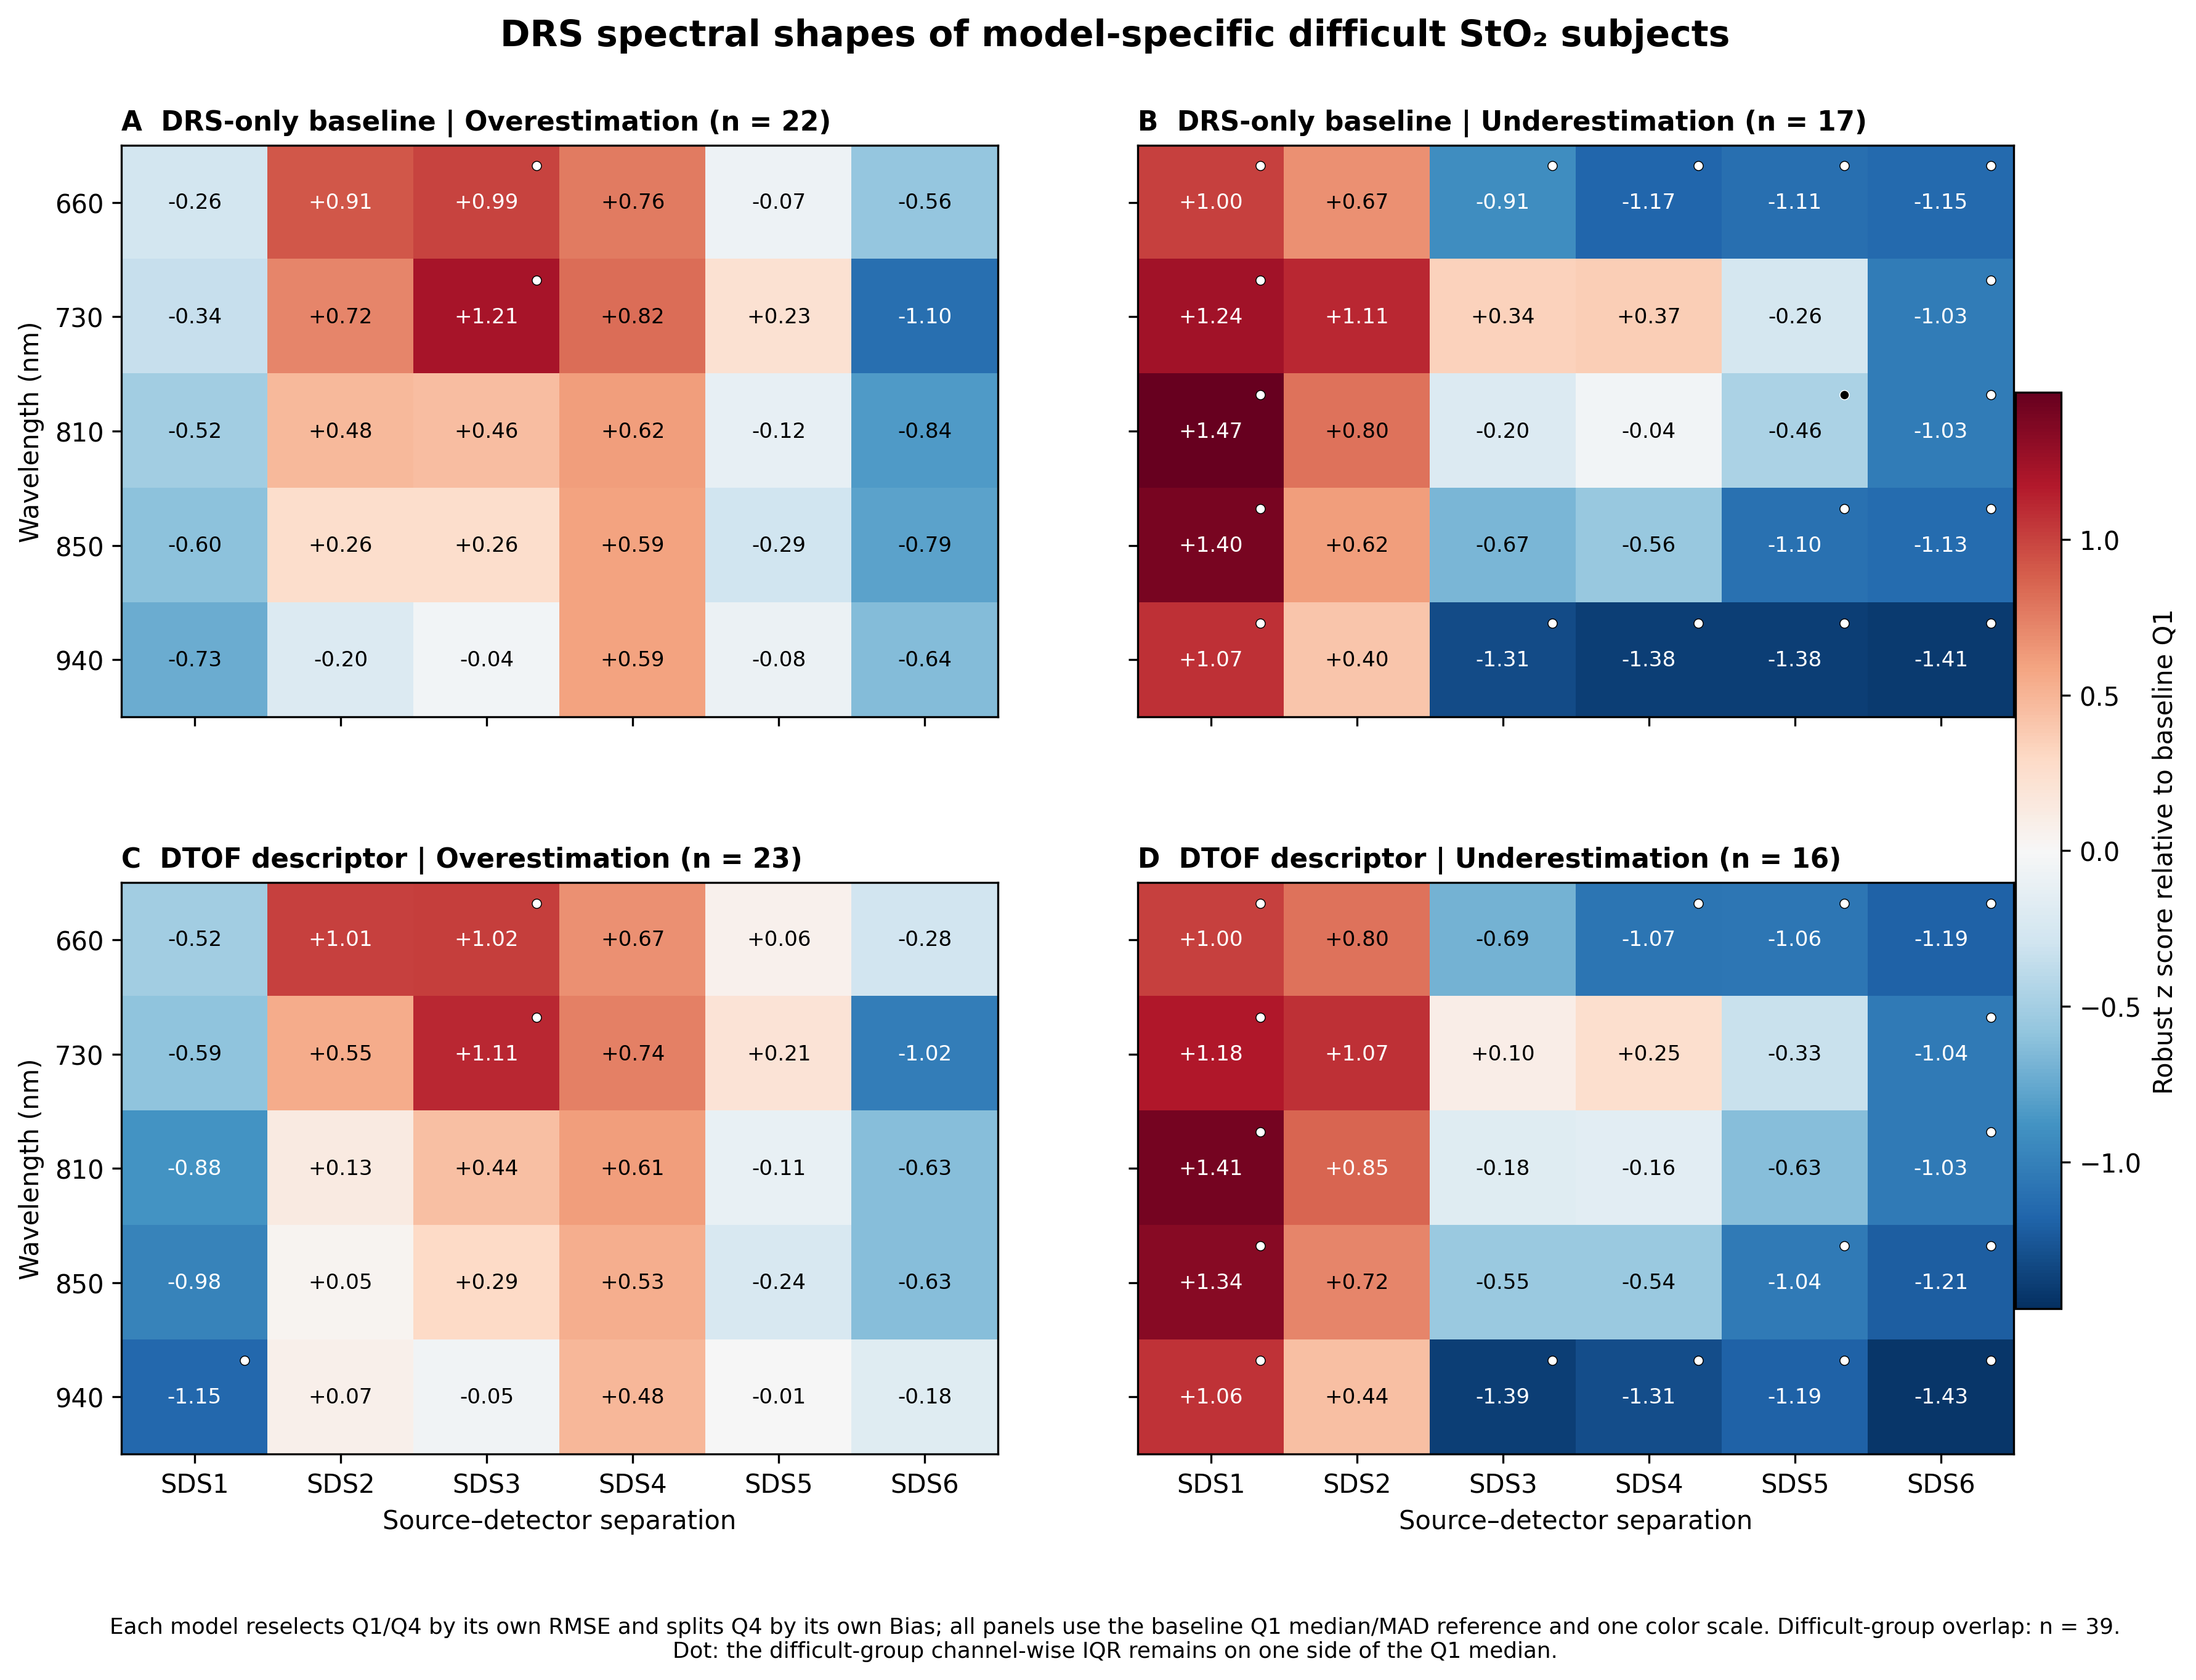

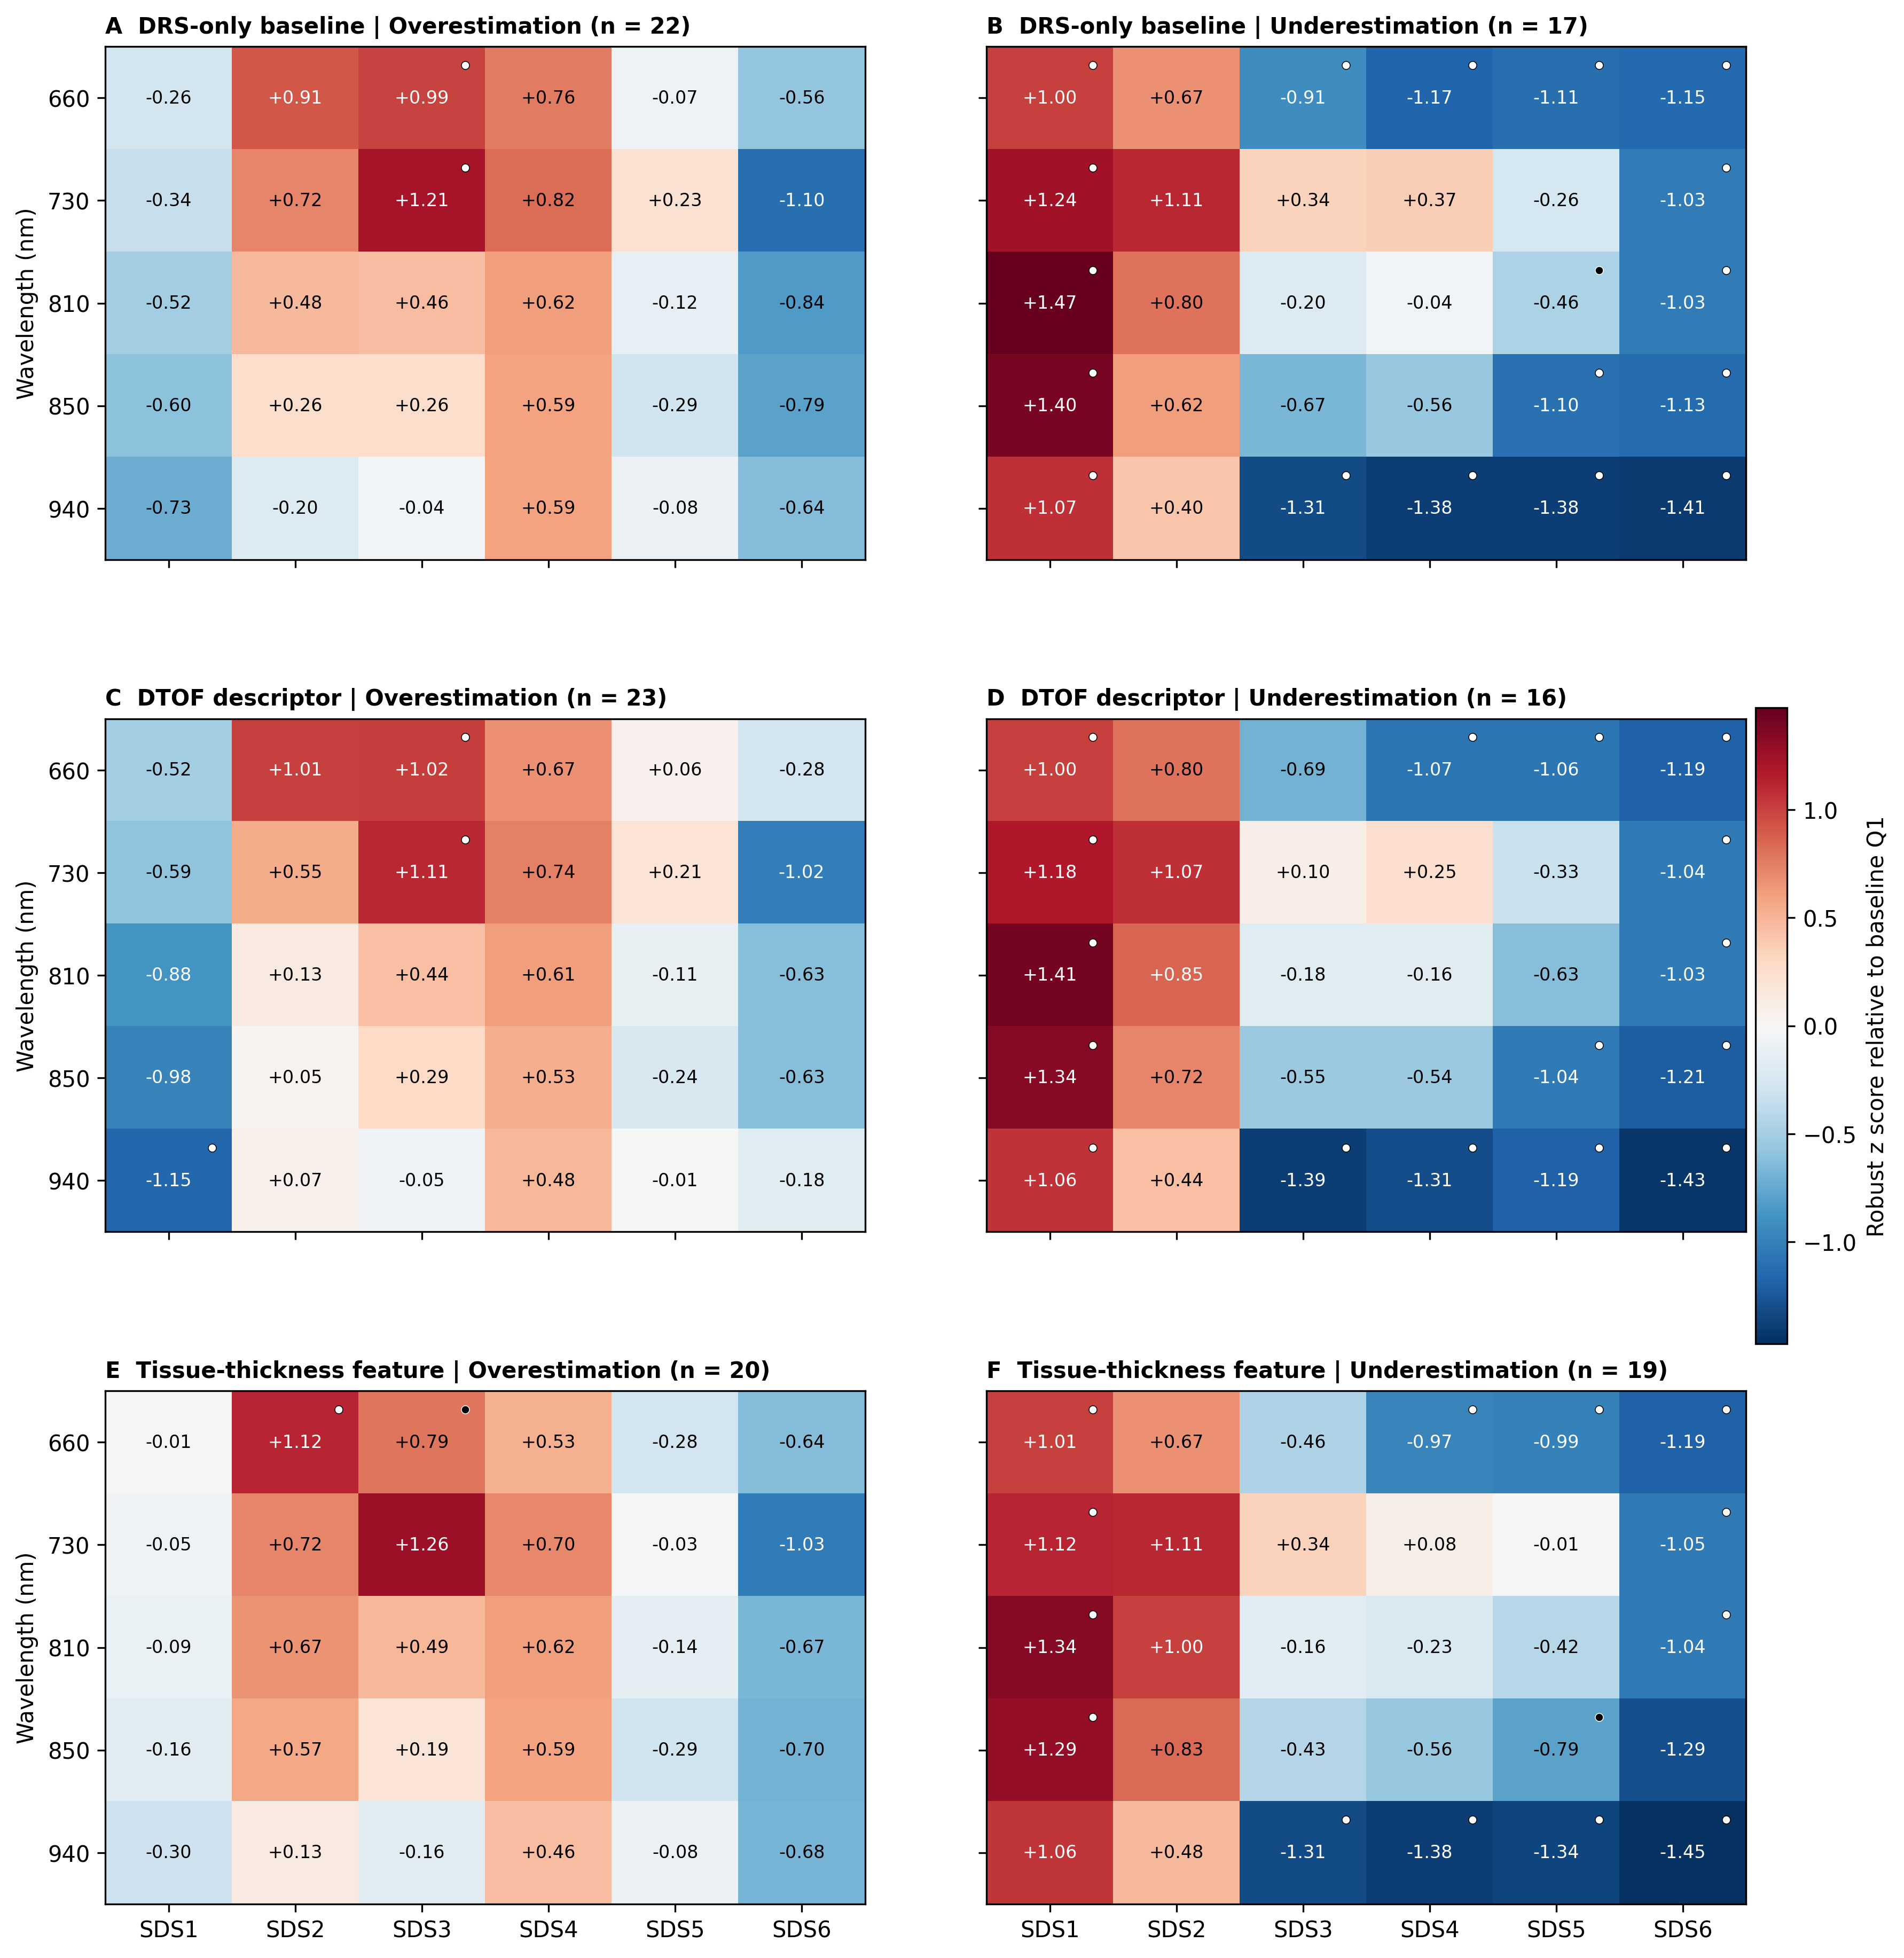

In [3]:
from IPython.display import Image, display

baseline_summaries = []
comparison_summaries = []
feature_comparison_summaries = []
for target_mode in BASELINE_DIRS:
    baseline = load_baseline_performance(BASELINE_DIRS[target_mode], target_mode)
    dtof = load_baseline_performance(DTOF_DIRS[target_mode], target_mode)
    thickness = load_baseline_performance(THICKNESS_DIRS[target_mode], target_mode)
    if any(len(frame) != EXPECTED_SUBJECTS for frame in (baseline, dtof, thickness)):
        raise ValueError(
            f'{target_mode}: expected {EXPECTED_SUBJECTS} subjects; '
            f'baseline={len(baseline)}, dtof={len(dtof)}, thickness={len(thickness)}'
        )
    baseline_summaries.append(
        make_subject_failure_figure(
            baseline, subject_ids, signatures, FIGURE_DIR, target_mode
        )
    )
    comparison_summaries.extend(
        make_subject_failure_comparison_figure(
            baseline, dtof, subject_ids, signatures, FIGURE_DIR, target_mode
        )
    )
    feature_comparison_summaries.extend(
        make_subject_failure_feature_comparison_figure(
            baseline, dtof, thickness, subject_ids, signatures, FIGURE_DIR, target_mode
        )
    )

TABLE_DIR.mkdir(parents=True, exist_ok=True)
baseline_table = pd.DataFrame(baseline_summaries)
comparison_table = pd.DataFrame(comparison_summaries)
feature_comparison_table = pd.DataFrame(feature_comparison_summaries)
baseline_table.to_csv(TABLE_DIR / 'subject_failure_summary.csv', index=False)
comparison_table.to_csv(
    TABLE_DIR / 'subject_failure_model_comparison_summary.csv', index=False
)
feature_comparison_table.to_csv(
    TABLE_DIR / 'subject_failure_feature_comparison_summary.csv', index=False
)
display(baseline_table)
display(comparison_table)
display(feature_comparison_table)
for target_mode in BASELINE_DIRS:
    display(Image(filename=str(FIGURE_DIR / f'subject_failure_{target_mode}.png'), width=1300))
    display(Image(filename=str(FIGURE_DIR / f'subject_failure_comparison_{target_mode}.png'), width=1300))
    display(Image(filename=str(FIGURE_DIR / f'subject_failure_feature_comparison_{target_mode}.png'), width=1300))